In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("house_data.csv")

Our result house_data.csv is a inner join result of the tables "king_county_house_details" and "king_county_house_sales"

The following columns not needed anymore were already deleated:
- house_id
- lat
- long

Filling missing column values

In [97]:
# Filling all NaN values with 0 under the assumption that NaN means no waterfront
df['waterfront'] = df.waterfront.fillna(0.0)

def strip_year_over_4_char(input: str):
    if len(input) > 4:
        return input[0:4]

# Strip unnecessay 0.0 from year (e.g 19910.0) in year_renovated and filling nan with 0 under the assumption that NaN means no renovation
df['yr_renovated'] = df.yr_renovated.astype(str)
df['yr_renovated'] = df.yr_renovated.apply(strip_year_over_4_char)
df['yr_renovated'] = df.yr_renovated.fillna(0)
df['yr_renovated'] = df.yr_renovated.astype(int)

# Filling NaN in view with mode (0)
df['view'] = df.view.fillna(0.0)

#df.head(20)

# Filling sqft_basement values by 0
df.sqft_basement = df.sqft_basement.fillna(0)
df.sqft_basement.value_counts(dropna=False)

sqft_basement
0.0       13279
600.0       217
700.0       209
500.0       209
800.0       201
          ...  
508.0         1
2810.0        1
20.0          1
274.0         1
248.0         1
Name: count, Length: 303, dtype: int64

The following column types need to be converted:
- bedrooms from float to int
- bathrooms from float to int
- floors from float to int
- waterfront from float to int
- view from float to int
-  sell_date from str to datetime     

In [98]:
df.bedrooms = df.bedrooms.astype(int)
df.bathrooms = df.bathrooms.astype(int)
df.floors = df.floors.astype(int)
df.waterfront = df.waterfront.astype(int)
df.view = df.view.astype(int)
df["view"] = df["view"].astype(int)
df.sell_date = pd.to_datetime(df.sell_date)
# 2.5.2014 -> 27.5.2015

Check duplicates in dataframe

In [99]:
# No further action needed because of no duplicates
df.duplicated().value_counts()

False    21597
Name: count, dtype: int64

Data cleaning

In [100]:
df.head(100)

# No further action needed because of no data that is out of the ordinary
df.house_id.value_counts()
df.bedrooms.value_counts()
df.bathrooms.value_counts()
df.sqft_living.value_counts()
df.sqft_lot.value_counts()
df.floors.value_counts()
df.waterfront.value_counts()
df.view.value_counts()
df.condition.value_counts()
df.grade.value_counts()
df.sqft_above.value_counts()
df.sqft_basement.value_counts()
df.yr_built.value_counts()
df.yr_renovated.value_counts()
df.zipcode.value_counts()
df.lat.value_counts()
df.long.value_counts()
df.sqft_living15.value_counts()
df.sqft_lot15.value_counts()
df.sell_date.value_counts()
df.sell_price.value_counts()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       21597 non-null  int64         
 1   bedrooms       21597 non-null  int64         
 2   bathrooms      21597 non-null  int64         
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  int64         
 6   waterfront     21597 non-null  int64         
 7   view           21597 non-null  int64         
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21597 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   21597 non-null  int64         
 14  zipcode        21597 non-null  int64         
 15  lat            2159

Filter every zipcode for central Seattle

In [101]:
# Filter out non-central zipcodes
df_zipcode_filtered = df[df['zipcode'] >= 98100].reset_index(drop=True)

Extract Year, Month and Month Name from Sell_Date for determining monthly prices

In [102]:
## New columns year and month from extract
df_zipcode_filtered['sell_year'] = df_zipcode_filtered.sell_date.dt.year.astype(str)
df_zipcode_filtered['sell_month'] = df_zipcode_filtered.sell_date.dt.month

# Map Month number to month name
df_zipcode_filtered['sell_month_name'] = df_zipcode_filtered.sell_month.map(
    {
        1:'January',
        2:'February',
        3:'March',
        4:'April',
        5:'May',
        6:'June',
        7:'July',
        8:'August',
        9:'September',
        10:'October',
        11:'November',
        12:'December',
    }
).astype(str)

# Create new column as concat of Month name and year to avoid adding may data for two years
df_zipcode_filtered['sell_year_month'] = (
    df_zipcode_filtered['sell_year'].astype(str) + 
    '-' + 
    df_zipcode_filtered['sell_month'].astype(str).str.zfill(2) # zfill(2) macht aus '5' -> '05'
)

Sort Dataframe for Selling Prices ascending to determine 40% to 60% price range of all central houses

In [103]:
# Sort sell_price ascending
df_zipcode_filtered.sort_values(by="sell_price",ascending=True,inplace=True)
df_zipcode_filtered.reset_index(inplace=True)

## Filter for 40% to 60% price data by index
percent40price_index = int(round(len(df_zipcode_filtered) * 0.4, 0))
percent40price = df_zipcode_filtered.sell_price.loc[percent40price_index]

median = df_zipcode_filtered.sell_price.median()

percent60price_index = int(round(len(df_zipcode_filtered) * 0.6, 0))
percent60price = df_zipcode_filtered.sell_price.loc[percent60price_index]

New Dataframe containing all houses in 40% to 60% price range

In [104]:
# New dataframe for price data 40% to 60%
df_40_to_60 = df_zipcode_filtered.iloc[percent40price_index:percent60price_index,1:].reset_index(drop=True)

Heatmap correlation of all variables corresponding to price to determine variable influence on price

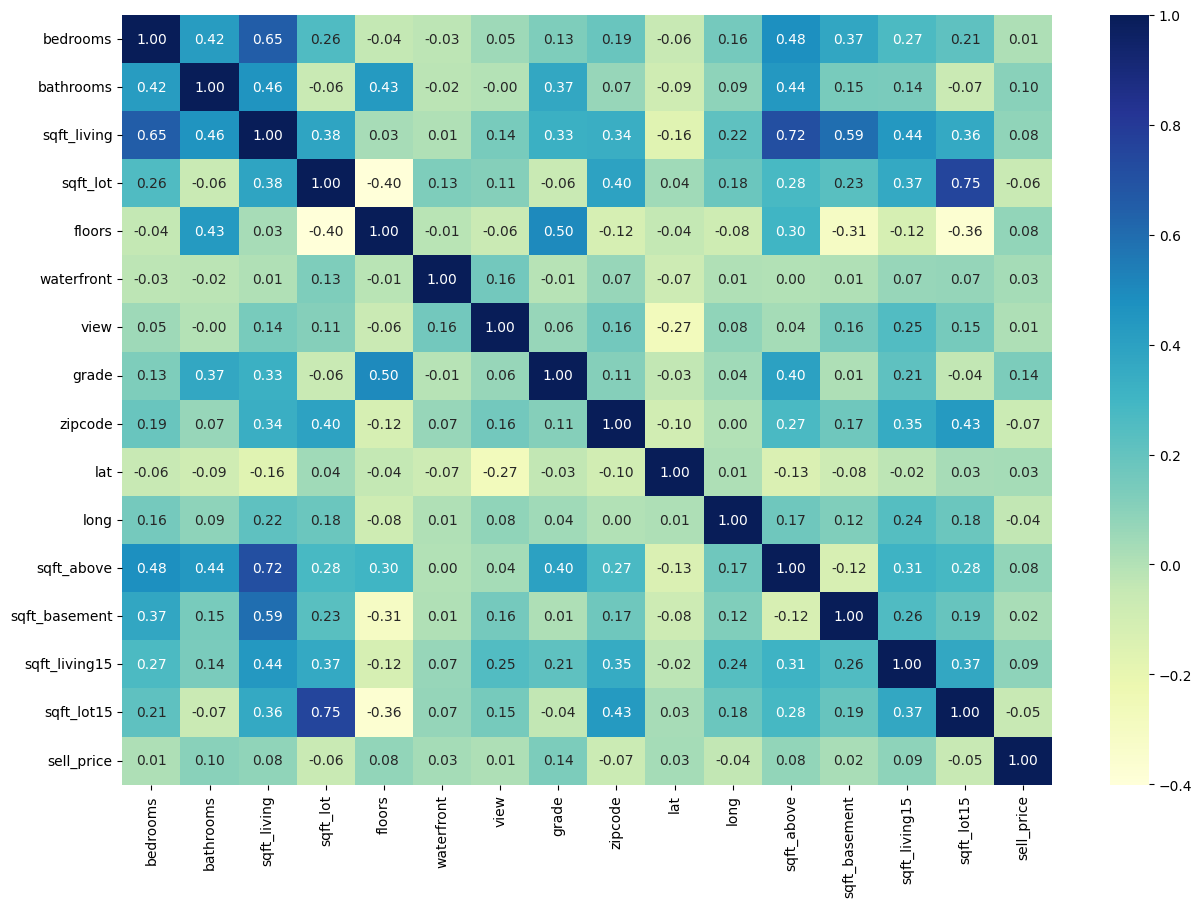

In [105]:
co_mtx = df_40_to_60[['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','grade','zipcode','lat','long','sqft_above','sqft_basement','sqft_living15','sqft_lot15','sell_price']].corr(numeric_only=True)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".2f")

# Display heatmap
plt.show()

Correlation of house features to Selling Price

,sell_price
grade,0.135
bathrooms,0.099
sqft_living15,0.088
sqft_living,0.084
floors,0.080
sqft_above,0.076
lat,0.035
waterfront,0.032
yr_built,0.028
sell_month,0.027


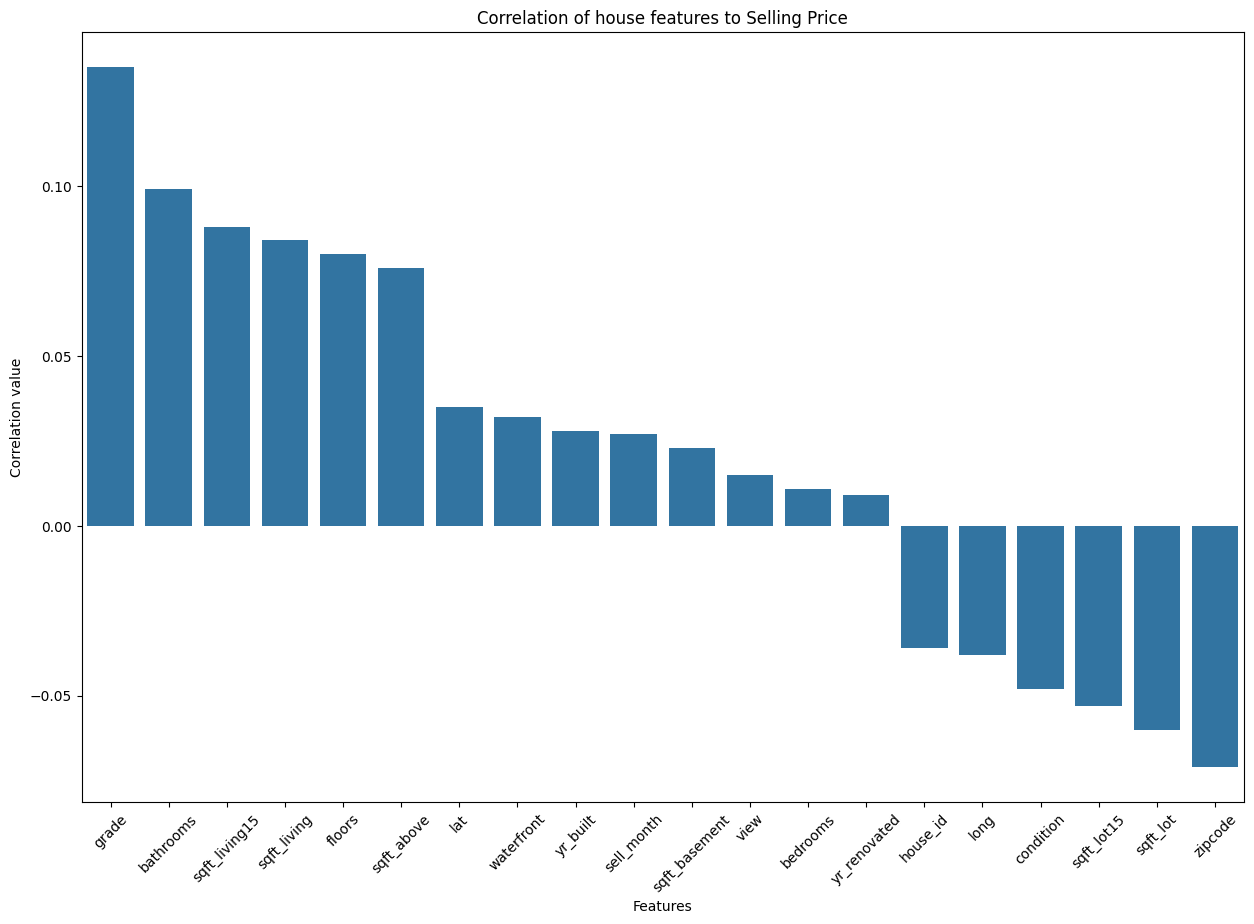

In [128]:
fig, ax = plt.subplots(figsize=(15, 10))
single_corr_df = df_40_to_60.corr(numeric_only=True)[['sell_price']].sort_values(by='sell_price', ascending=False)
single_corr_df = single_corr_df.drop("sell_price")
single_corr_df["sell_price"] = single_corr_df["sell_price"].round(3)
ax.set_title("Correlation of house features to Selling Price")
ax.set_xlabel("Features")
ax.set_ylabel("Correlation value")
sns.barplot(x=single_corr_df.index, y=single_corr_df["sell_price"])
plt.xticks(rotation=45) 
single_corr_df

Bar chart based on the grouped "year_month" column

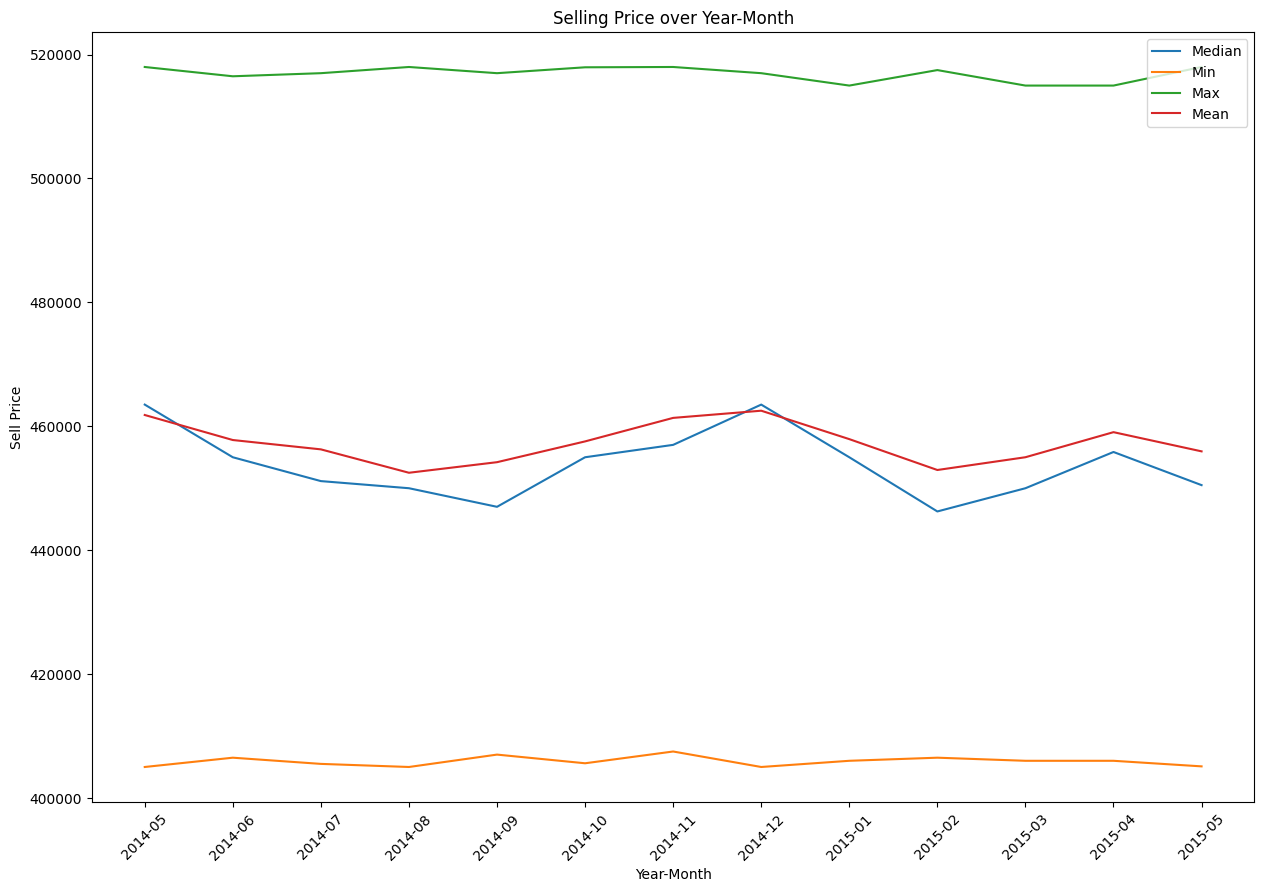

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
df_gb_year_month_median = df_40_to_60.groupby("sell_year_month")["sell_price"].median().to_frame()
df_gb_year_month_median.sort_values(by="sell_year_month")
# legend = ax.legend() 
sns.lineplot(data=df_gb_year_month_median, x="sell_year_month", y="sell_price", ax=ax, label="Median")
ax.set_title("Selling Price over Year-Month")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Sell Price [US $]")

plt.xticks(rotation=45) 

df_gb_year_month_min = df_40_to_60.groupby("sell_year_month")["sell_price"].min().to_frame()
df_gb_year_month_min.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_min, x="sell_year_month", y="sell_price", ax=ax, label="Min")

df_gb_year_month_max = df_40_to_60.groupby("sell_year_month")["sell_price"].max().to_frame()
df_gb_year_month_max.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_max, x="sell_year_month", y="sell_price", ax=ax, label="Max")

df_gb_year_month_mean = df_40_to_60.groupby("sell_year_month")["sell_price"].mean().to_frame()
df_gb_year_month_mean.sort_values(by="sell_year_month")
sns.lineplot(data=df_gb_year_month_mean, x="sell_year_month", y="sell_price", ax=ax, label="Mean")

# sns.lineplot(data=df_gb_year_month_median, x="sell_year_month", y="sell_price")
ax.legend() 


Line chart for hypothesis 1: sqrm price for lot and living space

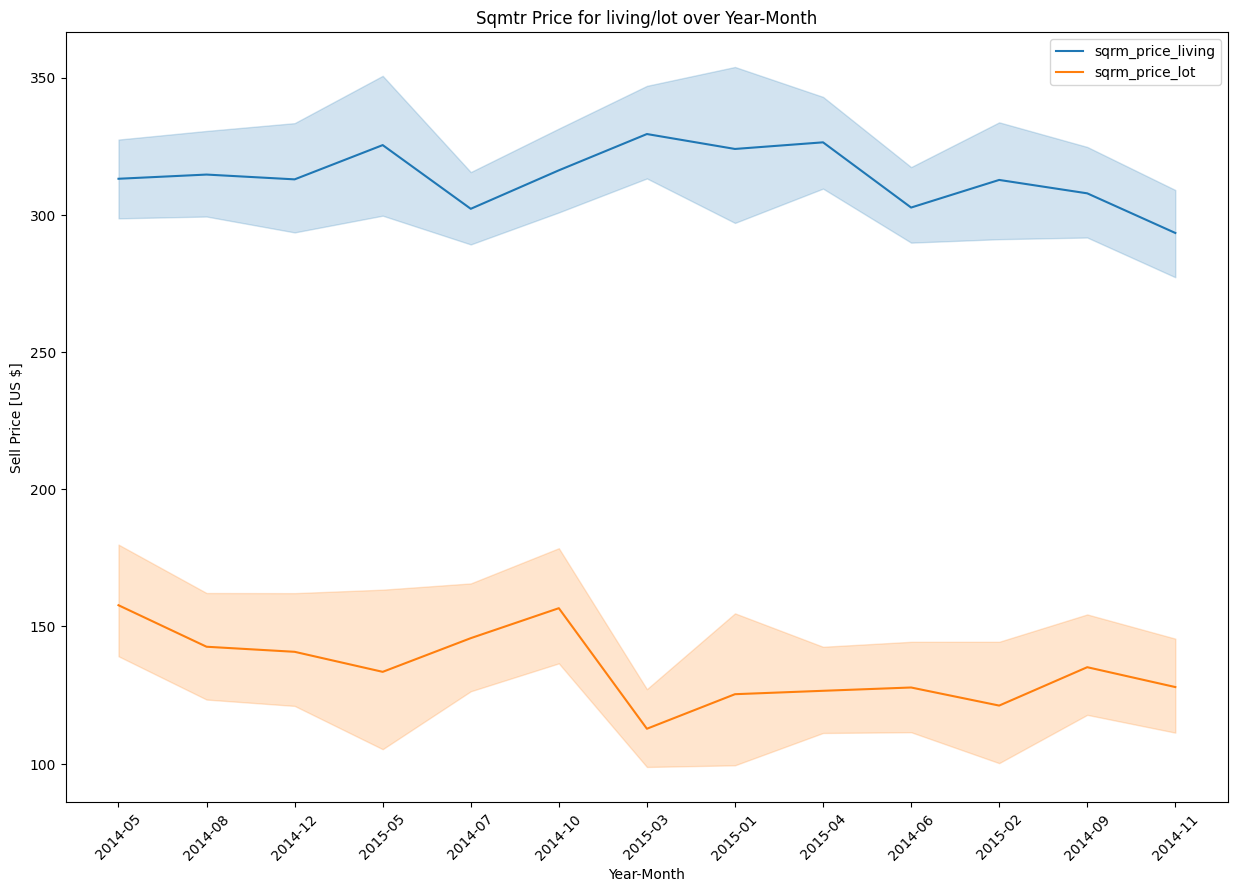

In [134]:
df_sqmt_price_lot_living = df_40_to_60.copy()
df_sqmt_price_lot_living["sqrm_price_living"] = df_sqmt_price_lot_living["sell_price"] / df_sqmt_price_lot_living["sqft_living"]
df_sqmt_price_lot_living["sqrm_price_living"] = df_sqmt_price_lot_living["sqrm_price_living"].round(2)

df_sqmt_price_lot_living["sqrm_price_lot"] = df_sqmt_price_lot_living["sell_price"] / df_sqmt_price_lot_living["sqft_lot"]
df_sqmt_price_lot_living["sqrm_price_lot"] = df_sqmt_price_lot_living["sqrm_price_lot"].round(2)
df_sqmt_price_lot_living


fig, ax = plt.subplots(figsize=(15, 10))
sns.lineplot(data=df_sqmt_price_lot_living, x="sell_year_month", y="sqrm_price_living", ax=ax, label="sqrm_price_living")
sns.lineplot(data=df_sqmt_price_lot_living, x="sell_year_month", y="sqrm_price_lot", ax=ax, label="sqrm_price_lot")
ax.set_title("Sqmtr Price for living/lot over Year-Month")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Sell Price [US $]")
plt.xticks(rotation=45) 


ax.legend() 